In [1]:
import scanpy as sc

In [ ]:
adata_sp_path = "/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_raw.h5ad"

In [ ]:
adata_sp = sc.read_h5ad(adata_sp_path)

In [ ]:
adata_sp.layers["counts"] = adata_sp.X.copy()
sc.pp.normalize_total(adata_sp, target_sum=1e4)
sc.pp.log1p(adata_sp)

In [ ]:
adata_sp_A61 = adata_sp[adata_sp.obs["donor"]=="A61"].copy()

In [2]:
adata_sp_A61 = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61.h5ad")

In [ ]:
adata_sp_A61.write_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61.h5ad")

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


### read spatial file with img

In [2]:
adata_sp_A61 = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61.h5ad")

In [5]:
adata_sp_A61.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 9671069 stored elements and shape (10278, 33538)>

### cell type annotation from processed data

In [4]:
adata_sp_A61_lognorm_hca = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_lognormalised.h5ad")

In [12]:
adata_sp_A61_lognorm_hca_A61 = adata_sp_A61_lognorm_hca[adata_sp_A61_lognorm_hca.obs["donor"]=="A61"].copy()

In [49]:
adata_sp_A61.obs["region_cell2loc"]

spot_id
HCAHeartST11290657_AAACAACGAATAGTTC-1    AVN
HCAHeartST11290657_AAACAATCTACTAGCA-1    AVN
HCAHeartST11290657_AAACAGAGCGACTCCT-1    AVN
HCAHeartST11290657_AAACCGGAAATGTTAA-1    AVN
HCAHeartST11290657_AAACCGGGTAGGTACC-1    AVN
                                        ... 
HCAHeartST11290662_TTGTTCTAGATACGCT-1    AVN
HCAHeartST11290662_TTGTTTCACATCCAGG-1    AVN
HCAHeartST11290662_TTGTTTCATTAGTCTA-1    AVN
HCAHeartST11290662_TTGTTTCCATACAACT-1    AVN
HCAHeartST11290662_TTGTTTGTGTAAATTC-1    AVN
Name: region_cell2loc, Length: 10278, dtype: category
Categories (1, object): ['AVN']

In [33]:
cols_to_add = adata_sp_A61_lognorm_hca_A61.obs.columns.difference(adata_sp_A61.obs.columns)

test = adata_sp_A61.obs.join(
    adata_sp_A61_lognorm_hca_A61.obs[cols_to_add],
    how="inner",
)


In [42]:
import polars as pl
pl.from_dataframe(test).columns

/tmp/ipykernel_3107563/3735121135.py:2: UserWarning: Failed to convert dataframe using PyCapsule Interface with exception: ImportError("Missing optional dependency 'pyarrow'.  Use pip or conda to install pyarrow.").
Falling back to Dataframe Interchange Protocol, which is known to be less robust.
  pl.from_dataframe(test).columns


['in_tissue',
 'array_row',
 'array_col',
 'sample',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'mt_frac',
 'n_counts',
 'n_genes',
 'annotation_JC',
 'sangerID',
 'Publication',
 'combinedID',
 'donor',
 'donor_type',
 'region',
 'region_finest',
 'age',
 'gender',
 'facility',
 'cell_or_nuclei',
 'modality',
 'kit_10x',
 'flushed',
 'region_cell2loc',
 'AVN_P_cell',
 'AVN_bundle_cell',
 'Adip1',
 'Adip2',
 'Adip3',
 'Adip4',
 'B',
 'B_plasma',
 'CD14+Mo',
 'CD16+Mo',
 'CD4+T_Tfh',
 'CD4+T_Th1',
 'CD4+T_Th2',
 'CD4+T_act',
 'CD4+T_naive',
 'CD4+T_reg',
 'CD8+T_cytox',
 'CD8+T_em',
 'CD8+T_te',
 'CD8+T_trans',
 'DC',
 'EC10_CMC-like',
 'EC1_cap',
 'EC2_cap',
 'EC3_cap',
 'EC4_immune',
 'EC5_art',
 'EC6_ven',
 'EC7_endocardial',
 'EC8_ln',
 'EC9_FB-like',
 'FB1',
 'FB2',
 'FB3',
 'FB4_activated',
 'FB5',
 'FB6',
 '

In [51]:
# we have tissue regions / compartments instead of cell types
test["annotation_final"].head()

spot_id
HCAHeartST11290657_AAACAACGAATAGTTC-1    myocardium_ventricular
HCAHeartST11290657_AAACAATCTACTAGCA-1    myocardium_ventricular
HCAHeartST11290657_AAACAGAGCGACTCCT-1          cardiac_skeleton
HCAHeartST11290657_AAACCGGAAATGTTAA-1         myocardium_atrial
HCAHeartST11290657_AAACCGGGTAGGTACC-1          cardiac_skeleton
Name: annotation_final, dtype: category
Categories (7, object): ['AV_bundle', 'cardiac_skeleton', 'fibrosis', 'myocardium_atrial', 'myocardium_ventricular', 'node', 'vessel']

In [57]:
test[[
 'AVN_P_cell',
 'AVN_bundle_cell',
 'Adip1',
 'Adip2',
 'Adip3',
 'Adip4',
 'B',
 'B_plasma',
 'CD14+Mo',
 'CD16+Mo',
 'CD4+T_Tfh',
 'CD4+T_Th1',
 'CD4+T_Th2',
 'CD4+T_act',
 'CD4+T_naive',
 'CD4+T_reg',
 'CD8+T_cytox',
 'CD8+T_em',
 'CD8+T_te',
 'CD8+T_trans',
 'DC',
 'EC10_CMC-like',
 'EC1_cap',
 'EC2_cap',
 'EC3_cap',
 'EC4_immune',
 'EC5_art',
 'EC6_ven',
 'EC7_endocardial',
 'EC8_ln',
 'EC9_FB-like',
 'FB1',
 'FB2',
 'FB3',
 'FB4_activated',
 'FB5',
 'FB6',
 'ILC',
 'LYVE1+IGF1+MP',
 'LYVE1+MP_cycling',
 'LYVE1+TIMD4+MP',
 'MAIT-like',
 'Mast',
 'Meso',
 'MoMP',
 'NC1_glial',
 'NC2_glial_NGF+',
 'NC3_glial',
 'NC5_glial',
 'NC6_schwann',
 'NK_CD16hi',
 'NK_CD56hi',
 'Neut',
 'PC1_vent',
 'PC2_atria',
 'PC3_str',
 'PC4_CMC-like',
 'SAN_P_cell',
 'SMC1_basic',
 'SMC2_art',
 'T/NK_cycling',
 'aCM1',
 'aCM2',
 'aCM3',
 'aCM4',
 'aCM5',
 'gdT',
 'vCM1',
 'vCM2',
 'vCM3_stressed',
 'vCM4',
 'vCM5']].describe()

,AVN_P_cell,AVN_bundle_cell,Adip1,Adip2,Adip3,Adip4,B,B_plasma,CD14+Mo,CD16+Mo,...,aCM2,aCM3,aCM4,aCM5,gdT,vCM1,vCM2,vCM3_stressed,vCM4,vCM5
count,5243.000000,5035.000000,10278.000000,10278.000000,10278.000000,0.0,10278.000000,10278.000000,10278.000000,10278.000000,...,10278.000000,10278.000000,10278.000000,0.0,0.0,10278.000000,10278.000000,10278.000000,10278.000000,10278.000000
mean,0.327889,0.135751,0.034616,0.011915,0.011227,NaN,0.045217,0.020808,0.035918,0.210824,...,0.016361,0.076208,0.448614,NaN,NaN,0.081236,0.024313,0.056186,3.019303,0.098817
std,0.253930,0.230367,0.057902,0.030437,0.019359,NaN,0.027363,0.049877,0.019954,0.137813,...,0.061637,0.140251,0.506656,NaN,NaN,0.070077,0.022226,0.096437,1.997607,0.106133
min,0.007307,0.003150,0.000301,0.000225,0.000399,NaN,0.001369,0.000110,0.003794,0.021545,...,0.000194,0.000464,0.006486,NaN,NaN,0.000229,0.000150,0.000194,0.018188,0.000543
25%,0.168949,0.028933,0.010735,0.002486,0.003628,NaN,0.027660,0.003319,0.022020,0.103418,...,0.003357,0.012553,0.129386,NaN,NaN,0.033371,0.011518,0.016308,1.223418,0.029800
50%,0.262779,0.053422,0.020279,0.004865,0.006480,NaN,0.040181,0.006865,0.031445,0.172777,...,0.005945,0.025544,0.249002,NaN,NaN,0.066363,0.018723,0.028377,2.795097,0.063263
75%,0.407918,0.118259,0.039975,0.010439,0.011877,NaN,0.056327,0.017284,0.045276,0.290404,...,0.011769,0.068134,0.582369,NaN,NaN,0.108730,0.030320,0.053203,4.539674,0.132162
max,2.806418,2.220039,2.327144,0.733852,0.599509,NaN,0.594441,1.200499,0.295763,1.362561,...,3.498190,2.581768,4.596249,NaN,NaN,1.783084,0.498689,1.585160,14.158212,1.628163


In [58]:
score_cols = [
    'AVN_P_cell', 'AVN_bundle_cell', 'Adip1', 'Adip2', 'Adip3', 'Adip4', 'B',
    'B_plasma', 'CD14+Mo', 'CD16+Mo', 'CD4+T_Tfh', 'CD4+T_Th1', 'CD4+T_Th2',
    'CD4+T_act', 'CD4+T_naive', 'CD4+T_reg', 'CD8+T_cytox', 'CD8+T_em',
    'CD8+T_te', 'CD8+T_trans', 'DC', 'EC10_CMC-like', 'EC1_cap', 'EC2_cap',
    'EC3_cap', 'EC4_immune', 'EC5_art', 'EC6_ven', 'EC7_endocardial', 'EC8_ln',
    'EC9_FB-like', 'FB1', 'FB2', 'FB3', 'FB4_activated', 'FB5', 'FB6', 'ILC',
    'LYVE1+IGF1+MP', 'LYVE1+MP_cycling', 'LYVE1+TIMD4+MP', 'MAIT-like', 'Mast',
    'Meso', 'MoMP', 'NC1_glial', 'NC2_glial_NGF+', 'NC3_glial', 'NC5_glial',
    'NC6_schwann', 'NK_CD16hi', 'NK_CD56hi', 'Neut', 'PC1_vent', 'PC2_atria',
    'PC3_str', 'PC4_CMC-like', 'SAN_P_cell', 'SMC1_basic', 'SMC2_art',
    'T/NK_cycling', 'aCM1', 'aCM2', 'aCM3', 'aCM4', 'aCM5', 'gdT', 'vCM1',
    'vCM2', 'vCM3_stressed', 'vCM4', 'vCM5'
]

broad_map = {
    # conduction / nodal cardiomyocytes
    'AVN_P_cell': 'Conduction_Cardiomyocyte',
    'AVN_bundle_cell': 'Conduction_Cardiomyocyte',
    'SAN_P_cell': 'Conduction_Cardiomyocyte',

    # atrial / ventricular cardiomyocytes
    'aCM1': 'Atrial_Cardiomyocyte',
    'aCM2': 'Atrial_Cardiomyocyte',
    'aCM3': 'Atrial_Cardiomyocyte',
    'aCM4': 'Atrial_Cardiomyocyte',
    'aCM5': 'Atrial_Cardiomyocyte',

    'vCM1': 'Ventricular_Cardiomyocyte',
    'vCM2': 'Ventricular_Cardiomyocyte',
    'vCM3_stressed': 'Ventricular_Cardiomyocyte',
    'vCM4': 'Ventricular_Cardiomyocyte',
    'vCM5': 'Ventricular_Cardiomyocyte',

    # Purkinje / specialized conduction-like
    'PC1_vent': 'Purkinje_like',
    'PC2_atria': 'Purkinje_like',
    'PC3_str': 'Purkinje_like',
    'PC4_CMC-like': 'Purkinje_like',

    # endothelial
    'EC1_cap': 'Endothelial',
    'EC2_cap': 'Endothelial',
    'EC3_cap': 'Endothelial',
    'EC4_immune': 'Endothelial',
    'EC5_art': 'Endothelial',
    'EC6_ven': 'Endothelial',
    'EC7_endocardial': 'Endothelial',
    'EC8_ln': 'Endothelial',
    'EC9_FB-like': 'Endothelial',
    'EC10_CMC-like': 'Endothelial',

    # fibroblasts
    'FB1': 'Fibroblast',
    'FB2': 'Fibroblast',
    'FB3': 'Fibroblast',
    'FB4_activated': 'Fibroblast',
    'FB5': 'Fibroblast',
    'FB6': 'Fibroblast',

    # smooth muscle / mural / mesothelial
    'SMC1_basic': 'Smooth_Muscle',
    'SMC2_art': 'Smooth_Muscle',
    'Meso': 'Mesothelial',

    # adipocytes
    'Adip1': 'Adipocyte',
    'Adip2': 'Adipocyte',
    'Adip3': 'Adipocyte',
    'Adip4': 'Adipocyte',

    # immune: B / plasma
    'B': 'B_cell',
    'B_plasma': 'Plasma_cell',

    # immune: T / NK / ILC
    'CD4+T_Tfh': 'T_cell',
    'CD4+T_Th1': 'T_cell',
    'CD4+T_Th2': 'T_cell',
    'CD4+T_act': 'T_cell',
    'CD4+T_naive': 'T_cell',
    'CD4+T_reg': 'T_cell',
    'CD8+T_cytox': 'T_cell',
    'CD8+T_em': 'T_cell',
    'CD8+T_te': 'T_cell',
    'CD8+T_trans': 'T_cell',
    'gdT': 'T_cell',
    'MAIT-like': 'T_cell',
    'T/NK_cycling': 'T_NK_cell',
    'NK_CD16hi': 'NK_cell',
    'NK_CD56hi': 'NK_cell',
    'ILC': 'ILC',

    # myeloid
    'CD14+Mo': 'Monocyte_Macrophage',
    'CD16+Mo': 'Monocyte_Macrophage',
    'LYVE1+IGF1+MP': 'Monocyte_Macrophage',
    'LYVE1+MP_cycling': 'Monocyte_Macrophage',
    'LYVE1+TIMD4+MP': 'Monocyte_Macrophage',
    'MoMP': 'Monocyte_Macrophage',
    'DC': 'Dendritic',
    'Neut': 'Neutrophil',
    'Mast': 'Mast_cell',

    # neural / glial / Schwann
    'NC1_glial': 'Glial_Schwann',
    'NC2_glial_NGF+': 'Glial_Schwann',
    'NC3_glial': 'Glial_Schwann',
    'NC5_glial': 'Glial_Schwann',
    'NC6_schwann': 'Glial_Schwann',
}

In [61]:
import pandas as pd


# make sure numeric
scores = test[score_cols].apply(pd.to_numeric, errors='coerce')

# broad score matrix
broad_scores = pd.DataFrame(index=test.index)

for fine, broad in broad_map.items():
    if fine in scores.columns:
        if broad not in broad_scores.columns:
            broad_scores[broad] = 0.0
        broad_scores[broad] = broad_scores[broad].add(scores[fine].fillna(0), fill_value=0)

In [64]:
test["broad_celltype"] = broad_scores.idxmax(axis=1)
test["broad_celltype_score"] = broad_scores.max(axis=1)

In [69]:
test["cell_lable"] = test["broad_celltype"]

In [89]:
# top 2 broad types
top2 = broad_scores.apply(lambda row: row.nlargest(2).index.tolist(), axis=1)
top2_scores = broad_scores.apply(lambda row: row.nlargest(2).values.tolist(), axis=1)

test["broad_celltype_top2"] = top2.str[0] + "|" + top2.str[1]
test["broad_celltype_margin"] = [
    vals[0] - vals[1] if len(vals) > 1 else float("nan")
    for vals in top2_scores
]

In [91]:
adata_sp_A61.obs = test

In [72]:
adata_sp_A61.obs.head()


,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,annotation_final,gdT,vCM1,vCM2,vCM3_stressed,vCM4,vCM5,broad_celltype,broad_celltype_score,cell_lable
spot_id,,,,,,,,,,,,,,,,,,,,,
HCAHeartST11290657_AAACAACGAATAGTTC-1,1,0,16,HCAHeartST11290657,1227,7.113142,3086.0,8.034955,45.268957,52.786779,...,myocardium_ventricular,NaN,0.059522,0.023024,0.030238,8.035143,0.506844,Ventricular_Cardiomyocyte,8.654772,Ventricular_Cardiomyocyte
HCAHeartST11290657_AAACAATCTACTAGCA-1,1,3,43,HCAHeartST11290657,571,6.349139,1073.0,6.979145,44.641193,54.426841,...,myocardium_ventricular,NaN,0.027643,0.012653,0.021668,3.204051,0.080626,Ventricular_Cardiomyocyte,3.346641,Ventricular_Cardiomyocyte
HCAHeartST11290657_AAACAGAGCGACTCCT-1,1,14,94,HCAHeartST11290657,642,6.466145,1134.0,7.034388,38.624339,47.795414,...,cardiac_skeleton,NaN,0.042561,0.020730,0.073389,1.347330,0.034062,Ventricular_Cardiomyocyte,1.518072,Ventricular_Cardiomyocyte
HCAHeartST11290657_AAACCGGAAATGTTAA-1,1,54,124,HCAHeartST11290657,546,6.304449,1196.0,7.087574,51.421405,60.200669,...,myocardium_atrial,NaN,0.015643,0.008062,0.023945,0.547026,0.014180,Endothelial,0.763192,Endothelial
HCAHeartST11290657_AAACCGGGTAGGTACC-1,1,42,28,HCAHeartST11290657,495,6.206576,808.0,6.695799,37.747525,50.123762,...,cardiac_skeleton,NaN,0.024863,0.017944,0.023745,0.977834,0.038686,Ventricular_Cardiomyocyte,1.083072,Ventricular_Cardiomyocyte


## look at samples for this donor

In [7]:
adata_sp_A61.obs["annotation_JC"]

spot_id
HCAHeartST11290657_AAACAACGAATAGTTC-1    myocardium_ventricular
HCAHeartST11290657_AAACAATCTACTAGCA-1    myocardium_ventricular
HCAHeartST11290657_AAACAGAGCGACTCCT-1          cardiac_skeleton
HCAHeartST11290657_AAACCGGAAATGTTAA-1         myocardium_atrial
HCAHeartST11290657_AAACCGGGTAGGTACC-1          cardiac_skeleton
                                                  ...          
HCAHeartST11290662_TTGTTCTAGATACGCT-1    myocardium_ventricular
HCAHeartST11290662_TTGTTTCACATCCAGG-1    myocardium_ventricular
HCAHeartST11290662_TTGTTTCATTAGTCTA-1    myocardium_ventricular
HCAHeartST11290662_TTGTTTCCATACAACT-1    myocardium_ventricular
HCAHeartST11290662_TTGTTTGTGTAAATTC-1    myocardium_ventricular
Name: annotation_JC, Length: 10278, dtype: category
Categories (8, object): ['AVN', 'AV_bundle', 'AV_bundle_branch_left', 'cardiac_skeleton', 'fibrosis', 'myocardium_atrial', 'myocardium_ventricular', 'vessel']

In [11]:
 w_cell2loc.obs

,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,sangerID,region,donor,donor_type,...,CD4+T_Th1_abundance,CD4+T_Th2_abundance,CD4+T_reg_abundance,NC5_glial_abundance,aCM5_abundance,Adip4_abundance,NC3_glial_abundance,NC6_schwann_abundance,EC9_FB-like_abundance,gdT_abundance
spot_id,,,,,,,,,,,,,,,,,,,,,
HCAHeartST11290662_AAACAACGAATAGTTC-1,0,16,1663,7.416980,4484.0,8.408494,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_AAACAAGTATCTCCCA-1,50,102,1468,7.292337,5511.0,8.614683,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_AAACAATCTACTAGCA-1,3,43,964,6.872128,2407.0,7.786552,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_AAACACCAATAACTGC-1,59,19,1724,7.452982,5201.0,8.556798,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_AAACAGCTTTCAGAAG-1,43,9,1648,7.407924,4858.0,8.488588,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HCAHeartST11290662_TTGTTCTAGATACGCT-1,21,3,1053,6.960348,2537.0,7.839132,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_TTGTTTCACATCCAGG-1,58,42,1286,7.160069,2530.0,7.836370,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCAHeartST11290662_TTGTTTCATTAGTCTA-1,60,30,835,6.728629,1861.0,7.529407,HCAHeartST11290662,AVN,A61,DCD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_1574804/906302846.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


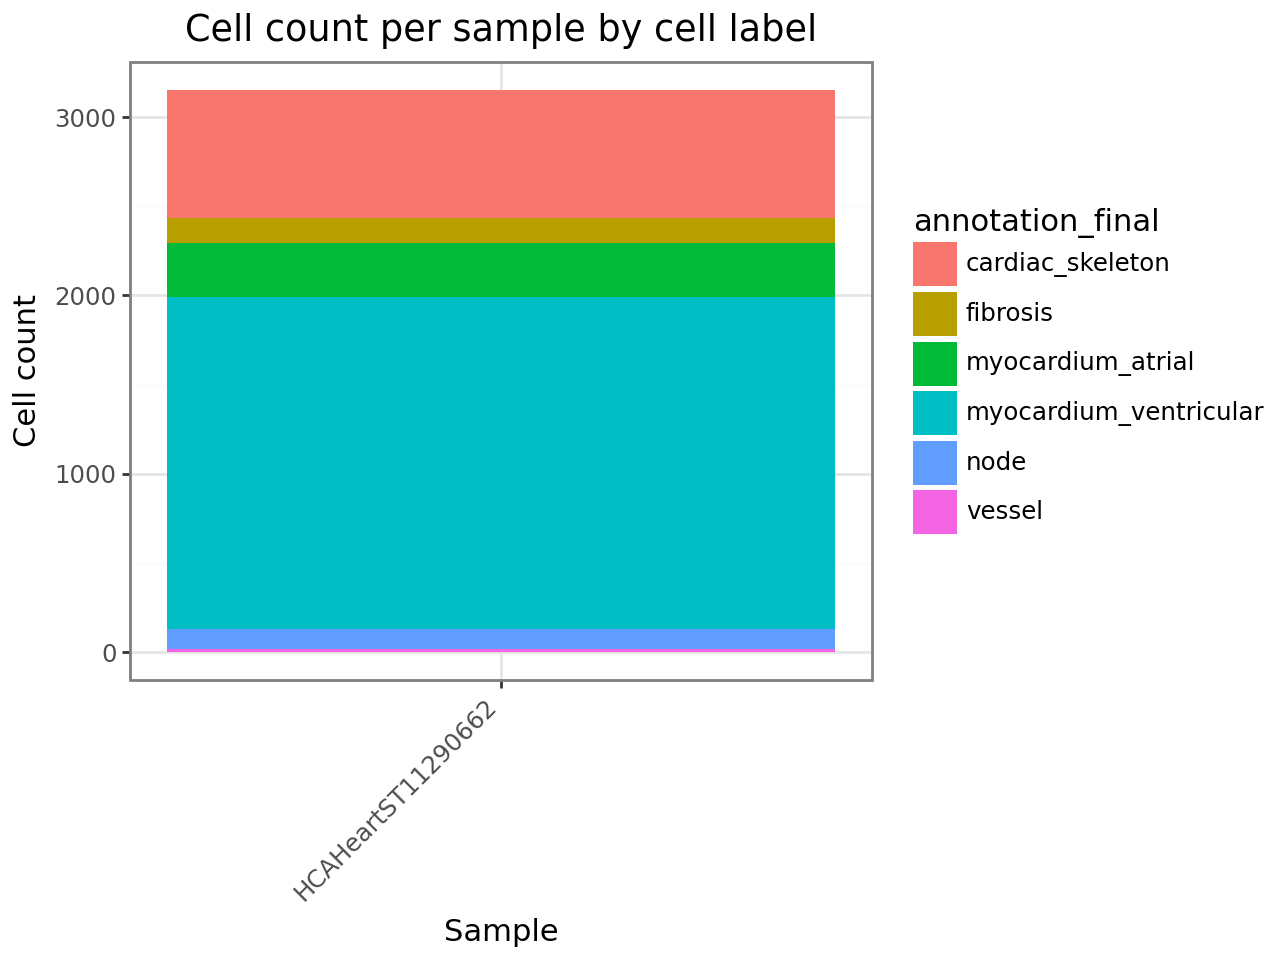

In [12]:

from plotnine import ggplot, aes, geom_bar, theme_bw, labs, theme, element_text

count_df = (
    w_cell2loc.obs
    .groupby(['sangerID', 'annotation_final'])
    .size()
    .reset_index(name='cell_count')
)

p = (
    ggplot(count_df, aes(x='sangerID', y='cell_count', fill='annotation_final'))
    + geom_bar(stat='identity')
    + theme_bw()
    + labs(
        x='Sample',
        y='Cell count',
        title='Cell count per sample by cell label'
    )
    + theme(axis_text_x=element_text(rotation=45, ha='right'))
)

p

/tmp/ipykernel_1574804/3157793124.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


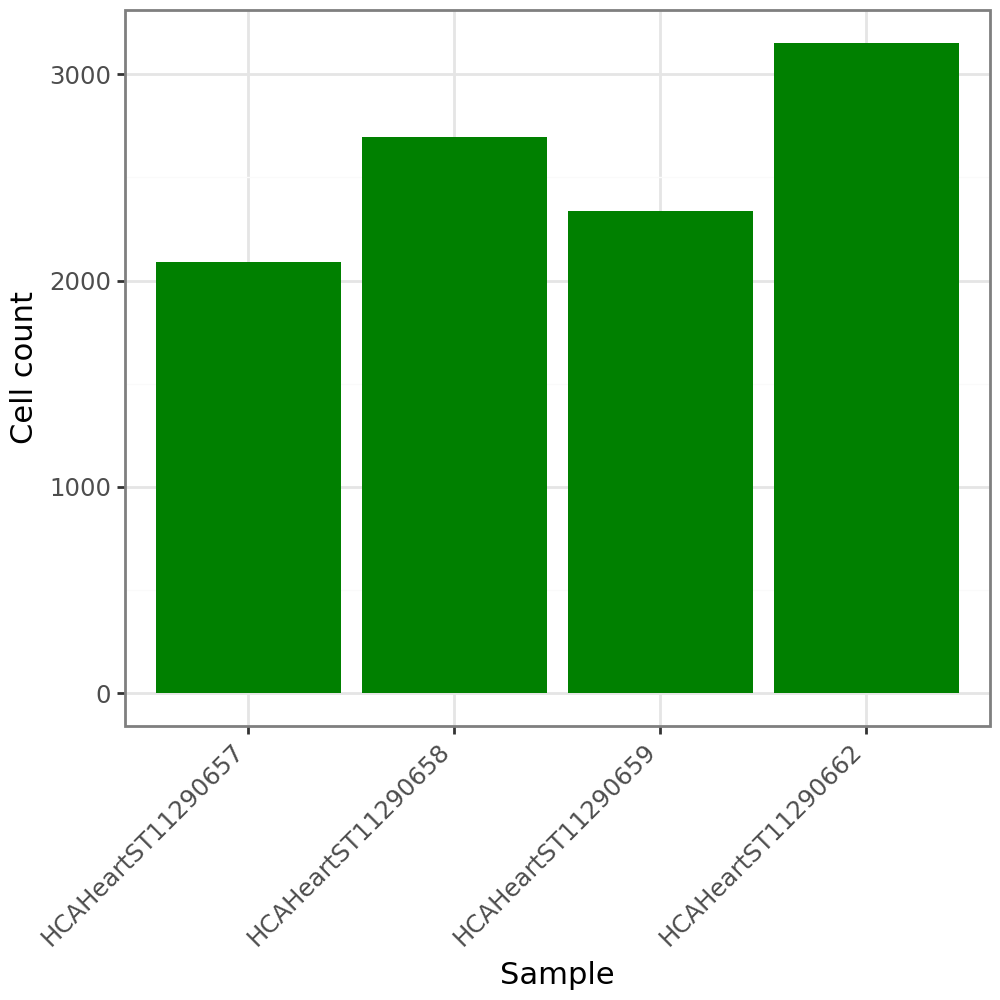

In [38]:
count_df = (
    adata_sp_A61.obs
    .groupby(['sample'])
    .size()
    .reset_index(name='cell_count')
)

p = (
    ggplot(count_df, aes(x='sample', y='cell_count'))
    + geom_bar(stat='identity', fill='green')
    + theme_bw()
    + labs(
        x='Sample',
        y='Cell count',
        title=''
    )
    + theme(
        axis_text_x=element_text(rotation=45, ha='right'),
        figure_size=(5, 5)  # narrower width
    )
)

p


/tmp/ipykernel_1574804/922232666.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


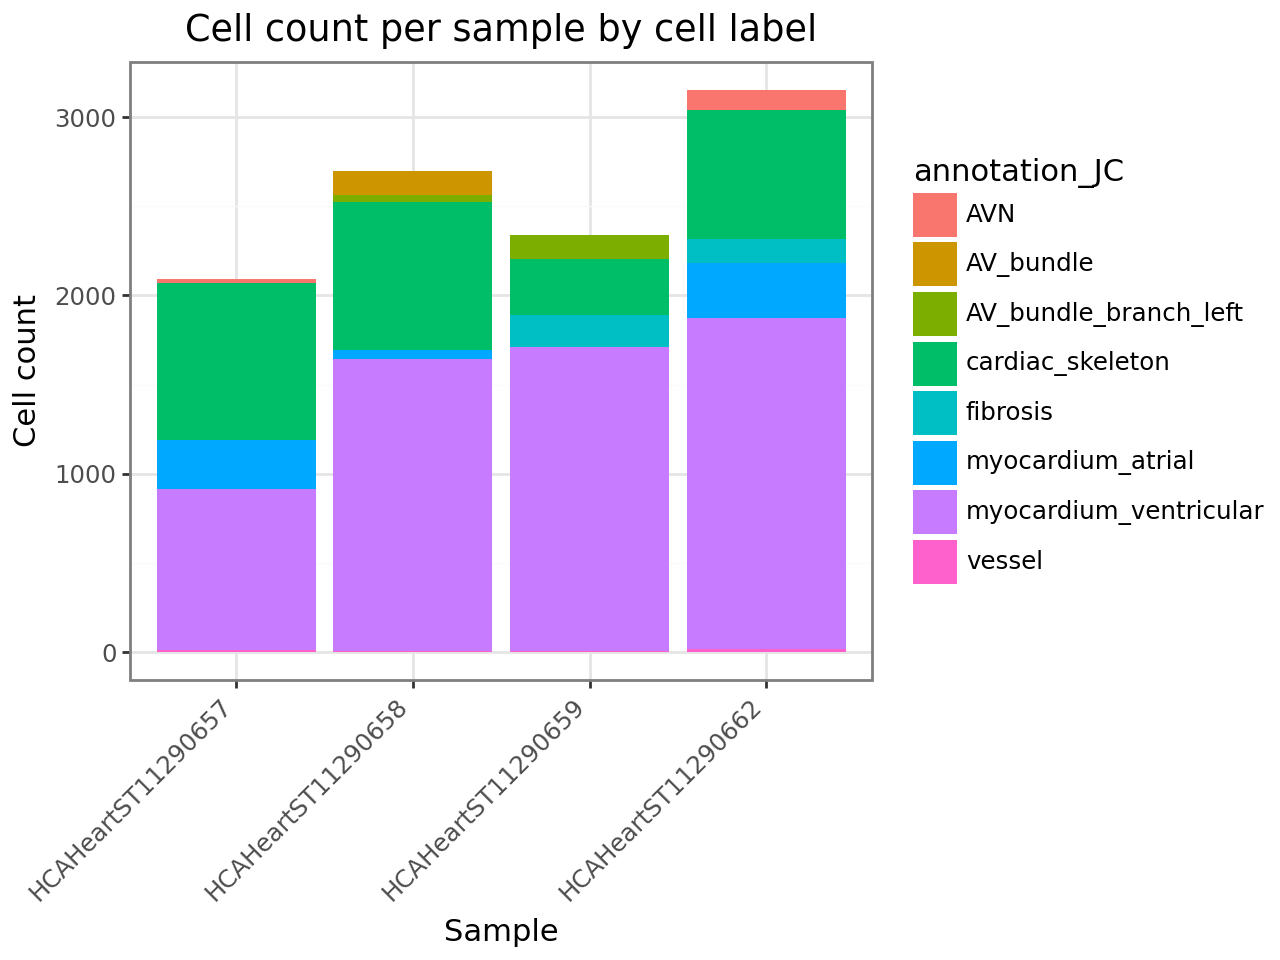

In [8]:

from plotnine import ggplot, aes, geom_bar, theme_bw, labs, theme, element_text

count_df = (
    adata_sp_A61.obs
    .groupby(['sample', 'annotation_JC'])
    .size()
    .reset_index(name='cell_count')
)

p = (
    ggplot(count_df, aes(x='sample', y='cell_count', fill='annotation_JC'))
    + geom_bar(stat='identity')
    + theme_bw()
    + labs(
        x='Sample',
        y='Cell count',
        title='Cell count per sample by cell label'
    )
    + theme(axis_text_x=element_text(rotation=45, ha='right'))
)

p

/tmp/ipykernel_3107563/241222871.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


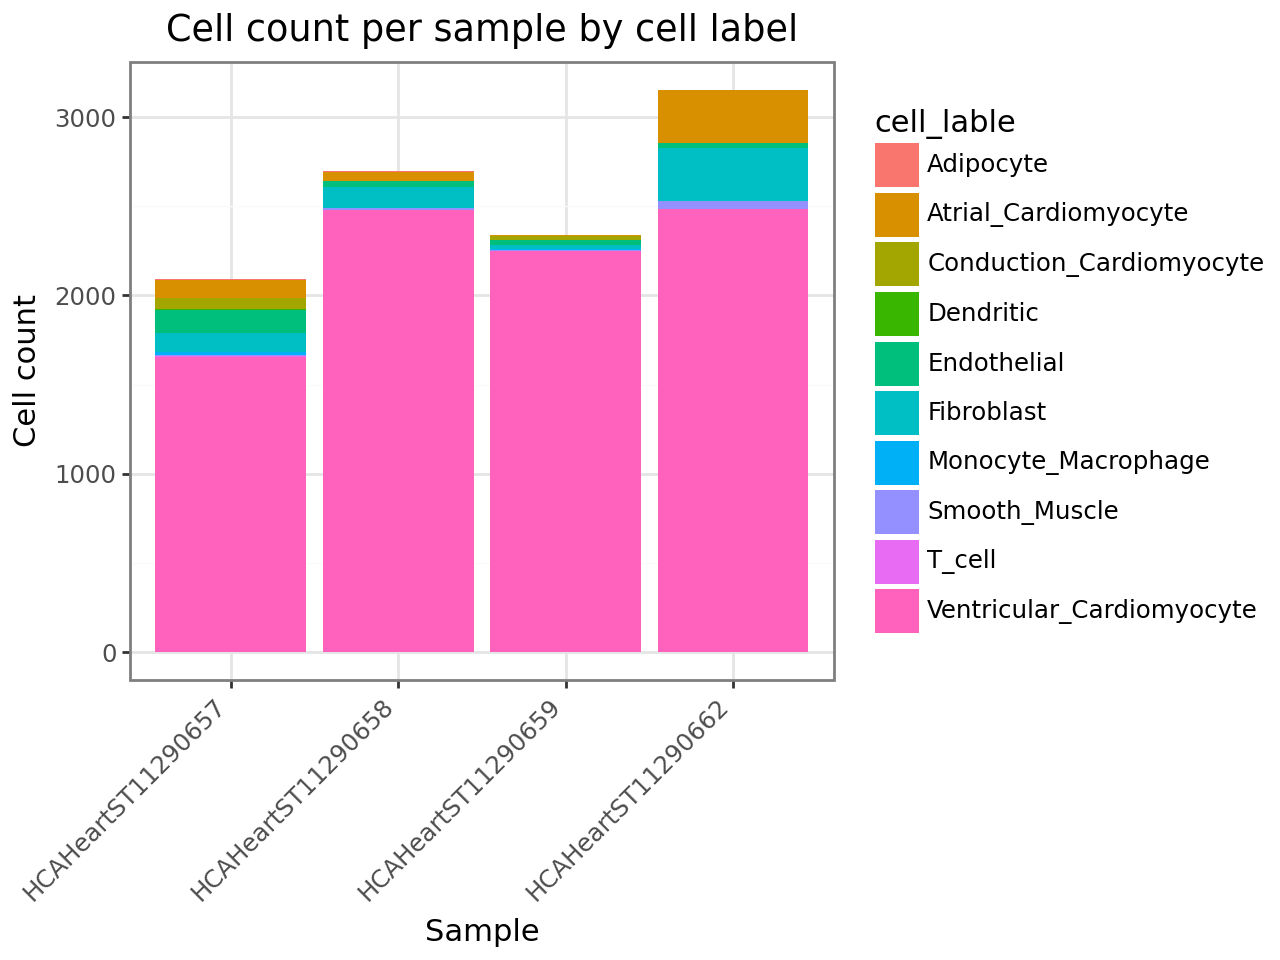

In [102]:

from plotnine import ggplot, aes, geom_bar, theme_bw, labs, theme, element_text

count_df = (
    adata_sp_A61.obs
    .groupby(['sample', 'cell_lable'])
    .size()
    .reset_index(name='cell_count')
)

p = (
    ggplot(count_df, aes(x='sample', y='cell_count', fill='cell_lable'))
    + geom_bar(stat='identity')
    + theme_bw()
    + labs(
        x='Sample',
        y='Cell count',
        title='Cell count per sample by cell label'
    )
    + theme(axis_text_x=element_text(rotation=45, ha='right'))
)

p

In [77]:
adata_sp_A61.uns["spatial"].keys()

dict_keys(['HCAHeartST10238251', 'HCAHeartST10238252', 'HCAHeartST10238253', 'HCAHeartST10550730', 'HCAHeartST10550732', 'HCAHeartST10659157', 'HCAHeartST10659158', 'HCAHeartST10659159', 'HCAHeartST10659160', 'HCAHeartST11099523', 'HCAHeartST11099524', 'HCAHeartST11290656', 'HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290660', 'HCAHeartST11290661', 'HCAHeartST11290662', 'HCAHeartST11350375', 'HCAHeartST11350376', 'HCAHeartST11350377', 'HCAHeartST12992072', 'HCAHeartST12992073', 'HCAHeartST12992074', 'HCAHeartST12992075', 'HCAHeartST13228103', 'HCAHeartST13228104', 'HCAHeartST13228105', 'HCAHeartST13228106', 'HCAHeartST13233996', 'HCAHeartST13233997', 'HCAHeartST13233998', 'HCAHeartST13233999', 'HCAHeartST8795933', 'HCAHeartST8795934', 'HCAHeartST8795935', 'HCAHeartST8795936', 'HCAHeartST8795937', 'HCAHeartST8795938', 'HCAHeartST8795939', 'HCAHeartST8795940', 'HCAHeartST9341982', 'HCAHeartST9341983', 'HCAHeartST9341984', 'HCAHeartST9383352', 'HCAHeartST

['HCAHeartST10238251', 'HCAHeartST10238252', 'HCAHeartST10238253', 'HCAHeartST10550730', 'HCAHeartST10550732', 'HCAHeartST10659157', 'HCAHeartST10659158', 'HCAHeartST10659159', 'HCAHeartST10659160', 'HCAHeartST11099523', 'HCAHeartST11099524', 'HCAHeartST11290656', 'HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290660', 'HCAHeartST11290661', 'HCAHeartST11290662', 'HCAHeartST11350375', 'HCAHeartST11350376', 'HCAHeartST11350377', 'HCAHeartST12992072', 'HCAHeartST12992073', 'HCAHeartST12992074', 'HCAHeartST12992075', 'HCAHeartST13228103', 'HCAHeartST13228104', 'HCAHeartST13228105', 'HCAHeartST13228106', 'HCAHeartST13233996', 'HCAHeartST13233997', 'HCAHeartST13233998', 'HCAHeartST13233999', 'HCAHeartST8795933', 'HCAHeartST8795934', 'HCAHeartST8795935', 'HCAHeartST8795936', 'HCAHeartST8795937', 'HCAHeartST8795938', 'HCAHeartST8795939', 'HCAHeartST8795940', 'HCAHeartST9341982', 'HCAHeartST9341983', 'HCAHeartST9341984', 'HCAHeartST9383352', 'HCAHeartST9383353', 

/tmp/ipykernel_3107563/2685567626.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


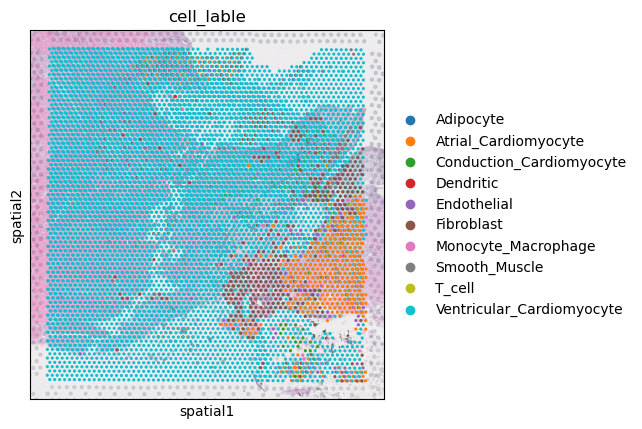

In [87]:
# check available spatial libraries
# check available spatial libraries
libs = list(adata_sp_A61.uns.get("spatial", {}).keys())
print(libs)

library_id = "HCAHeartST11290662" if "HCAHeartST11290662" in libs else libs[0]
print(library_id)

sc.pl.spatial(
    adata_sp_A61,
    library_id=library_id,
    img_key="hires",
    color="cell_lable",
)

## make light

In [112]:
adata_sp_A61_light = adata_sp_A61.copy()

# remove all uns from adata_sp_A61_light
samples_A61 = adata_sp_A61_light.obs["sample"].cat.categories
spatial_subdict = {
    k: adata_sp_A61_light.uns["spatial"][k]
    for k in samples_A61
    if k in adata_sp_A61_light.uns["spatial"]
}

adata_sp_A61_light.uns["spatial"] = spatial_subdict
adata_sp_A61_light.write_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.h5ad")

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release


In [113]:
adata_sp_A61_light = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.h5ad")

In [114]:
adata_sp_A61_light.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       ...
       'vCM1', 'vCM2', 'vCM3_stressed', 'vCM4', 'vCM5', 'broad_celltype',
       'broad_celltype_score', 'cell_lable', 'broad_celltype_top2',
       'broad_celltype_margin'],
      dtype='object', length=109)

In [119]:
path ="/nfs/home/students/m.back/swarm/backend/uploads/job_1773655682816_777ca607-5fc1-4602-aaa7-4f856c95c2e0/visium-OCT_AVN_norm_log1pA61_light.h5ad"

In [120]:
sc.read_h5ad(path)

AnnData object with n_obs × n_vars = 10278 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'n_counts', 'n_genes', 'annotation_JC', 'sangerID', 'Publication', 'combinedID', 'donor', 'donor_type', 'region', 'region_finest', 'age', 'gender', 'facility', 'cell_or_nuclei', 'modality', 'kit_10x', 'flushed', 'region_cell2loc', 'AVN_P_cell', 'AVN_bundle_cell', 'Adip1', 'Adip2', 'Adip3', 'Adip4', 'B', 'B_plasma', 'CD14+Mo', 'CD16+Mo', 'CD4+T_Tfh', 'CD4+T_Th1', 'CD4+T_Th2', 'CD4+T_act', 'CD4+T_naive', 'CD4+T_reg', 'CD8+T_cytox', 'CD8+T_em', 'CD8+T_te', 'CD8+T_trans', 'DC', 'EC10_CMC-like', 'EC1_cap', 'EC2_cap', 'EC3_cap', 'EC4_immune', 'EC5_art', 'EC6_ven', 'EC7_endocardial', 'EC8_ln', 'EC9_FB-like', 'FB1', 'FB2', 'FB3', 'FB4_activated', 'FB5', 'FB6', 'ILC', 'LY

In [121]:
import scanpy as sc

infile = "/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.h5ad"
outfile = "/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.fixed.h5ad"

adata = sc.read_h5ad(infile)

if "log1p" in adata.uns:
    log1p = adata.uns["log1p"]
    if isinstance(log1p, dict) and "base" in log1p and log1p["base"] is None:
        del log1p["base"]

adata.write_h5ad(outfile)

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release


In [124]:
adata.obs.rename(columns={"cell_lable": "cell_type"}, inplace=True)

In [125]:
adata.write_h5ad("visium-OCT_AVN_norm_log1pA61_light.fixed.h5ad")

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release


In [126]:
adata.write_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.fixed.h5ad")

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release


In [3]:
adata_light = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_norm_log1pA61_light.fixed.h5ad")

In [3]:
adata_light.uns["spatial"].keys()

dict_keys(['HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290662'])

In [7]:
adata_light.obs["sample"].unique()

['HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290662']
Categories (4, object): ['HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290662']

/tmp/ipykernel_1054873/3724834759.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


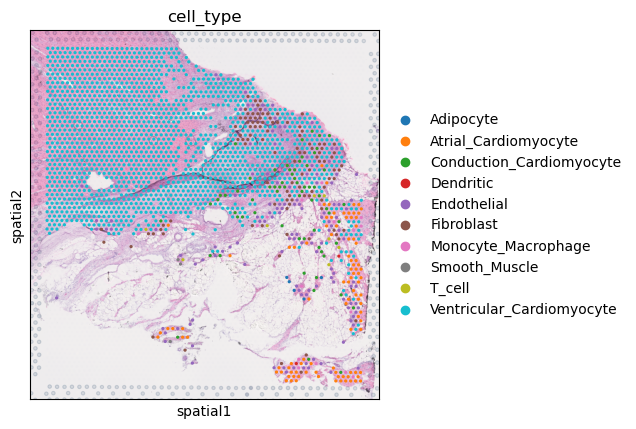

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/tmp/ipykernel_1054873/3724834759.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


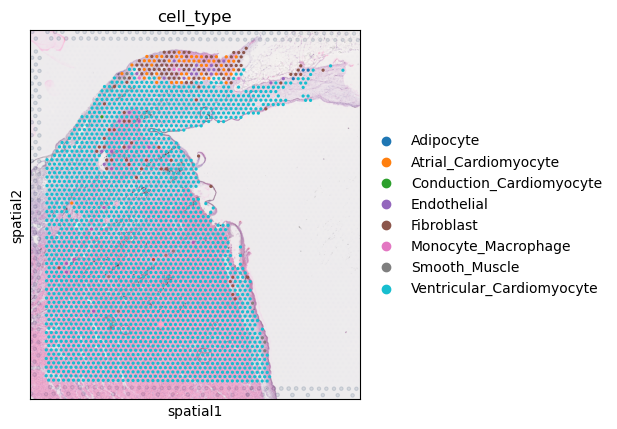

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/tmp/ipykernel_1054873/3724834759.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


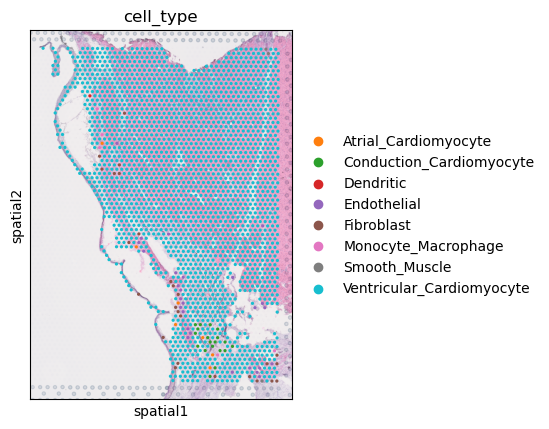

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/tmp/ipykernel_1054873/3724834759.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


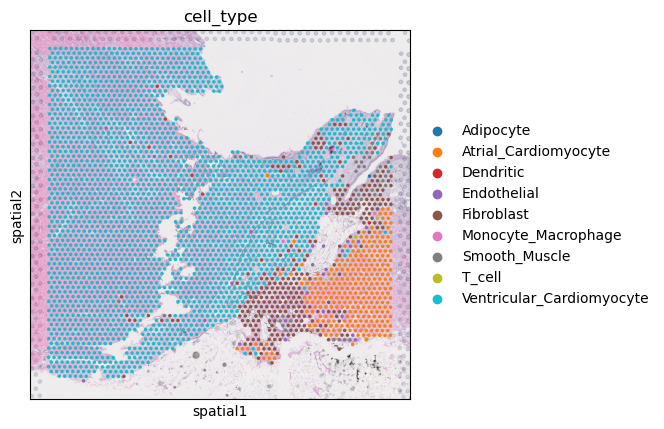

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [15]:
slice_dir = Path("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/single_slices")
for lib in adata_light.uns["spatial"].keys():
    this_lib_samples = adata_light[adata_light.obs["sample"] == lib].copy()
    sc.pl.spatial(
        this_lib_samples,
        library_id=lib,
        img_key="hires",
        color="cell_type",
    )
    #this_lib_samples remove uns["spatial"] except for the current library
    spatial_subdict = {
        k: this_lib_samples.uns["spatial"][k]
        for k in [lib]
        if k in this_lib_samples.uns["spatial"]
    }
    this_lib_samples.uns["spatial"] = spatial_subdict
    this_lib_samples.write_h5ad(slice_dir / f"{lib}_adata.h5ad")
    

# add annotation from paper

In [16]:
from pathlib import Path
import scanpy as sc
slice_dir = Path("/nfs/data3/mopitas/mapra/cell_atlas_data/visium/single_slices")

In [17]:
adata_HCAHeartST11290662 = sc.read_h5ad(slice_dir / "HCAHeartST11290662_adata.h5ad")

In [5]:
print(adata_HCAHeartST11290662.obs.columns.tolist())

['in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'n_counts', 'n_genes', 'annotation_JC', 'sangerID', 'Publication', 'combinedID', 'donor', 'donor_type', 'region', 'region_finest', 'age', 'gender', 'facility', 'cell_or_nuclei', 'modality', 'kit_10x', 'flushed', 'region_cell2loc', 'AVN_P_cell', 'AVN_bundle_cell', 'Adip1', 'Adip2', 'Adip3', 'Adip4', 'B', 'B_plasma', 'CD14+Mo', 'CD16+Mo', 'CD4+T_Tfh', 'CD4+T_Th1', 'CD4+T_Th2', 'CD4+T_act', 'CD4+T_naive', 'CD4+T_reg', 'CD8+T_cytox', 'CD8+T_em', 'CD8+T_te', 'CD8+T_trans', 'DC', 'EC10_CMC-like', 'EC1_cap', 'EC2_cap', 'EC3_cap', 'EC4_immune', 'EC5_art', 'EC6_ven', 'EC7_endocardial', 'EC8_ln', 'EC9_FB-like', 'FB1', 'FB2', 'FB3', 'FB4_activated', 'FB5', 'FB6', 'ILC', 'LYVE1+IGF1+MP', 'LYVE1+MP_cycling', 'LYVE1+TIMD4+MP', 'MAIT-l

In [5]:
adata_HCAHeartST11290662.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,vCM1,vCM2,vCM3_stressed,vCM4,vCM5,broad_celltype,broad_celltype_score,cell_type,broad_celltype_top2,broad_celltype_margin
spot_id,,,,,,,,,,,,,,,,,,,,,
HCAHeartST11290662_AAACAACGAATAGTTC-1,1,0,16,HCAHeartST11290662,1663,7.416980,4484.0,8.408494,42.930419,50.178412,...,0.295094,0.037845,0.103207,5.005702,0.263871,Ventricular_Cardiomyocyte,5.705719,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,4.804399
HCAHeartST11290662_AAACAAGTATCTCCCA-1,1,50,102,HCAHeartST11290662,1468,7.292337,5511.0,8.614683,61.767374,66.430775,...,0.022552,0.014770,0.024087,0.386745,0.010724,Atrial_Cardiomyocyte,2.594774,Atrial_Cardiomyocyte,Atrial_Cardiomyocyte|Fibroblast,1.815024
HCAHeartST11290662_AAACAATCTACTAGCA-1,1,3,43,HCAHeartST11290662,964,6.872128,2407.0,7.786552,50.103864,56.958870,...,0.116356,0.018534,0.121986,4.411305,0.064001,Ventricular_Cardiomyocyte,4.732183,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,4.255999
HCAHeartST11290662_AAACACCAATAACTGC-1,1,59,19,HCAHeartST11290662,1724,7.452982,5201.0,8.556798,47.413959,54.451067,...,0.112764,0.029460,0.145571,6.854216,0.114528,Ventricular_Cardiomyocyte,7.256539,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,6.115447
HCAHeartST11290662_AAACAGCTTTCAGAAG-1,1,43,9,HCAHeartST11290662,1648,7.407924,4858.0,8.488588,47.694524,53.746398,...,0.156693,0.026344,0.040879,6.432179,0.137133,Ventricular_Cardiomyocyte,6.793228,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,5.636828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HCAHeartST11290662_TTGTTCTAGATACGCT-1,1,21,3,HCAHeartST11290662,1053,6.960348,2537.0,7.839132,47.694127,54.434371,...,0.092786,0.012702,0.057502,3.534697,0.161541,Ventricular_Cardiomyocyte,3.859228,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,3.237142
HCAHeartST11290662_TTGTTTCACATCCAGG-1,1,58,42,HCAHeartST11290662,1286,7.160069,2530.0,7.836370,31.027668,39.328063,...,0.065781,0.018153,0.124392,1.526806,0.035284,Fibroblast,2.004893,Fibroblast,Fibroblast|Ventricular_Cardiomyocyte,0.234477
HCAHeartST11290662_TTGTTTCATTAGTCTA-1,1,60,30,HCAHeartST11290662,835,6.728629,1861.0,7.529407,46.265449,54.218162,...,0.051487,0.011019,0.081784,4.037649,0.049657,Ventricular_Cardiomyocyte,4.231595,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,3.696453


In [9]:
w_cell2loc = sc.read_h5ad("/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/HCAHeartST11290662.h5ad")

In [8]:
adata_HCAHeartST11290662.obs["cell_type"] #= w_cell2loc.obs["annotation_final"]

spot_id
HCAHeartST11290662_AAACAACGAATAGTTC-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_AAACAAGTATCTCCCA-1         Atrial_Cardiomyocyte
HCAHeartST11290662_AAACAATCTACTAGCA-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_AAACACCAATAACTGC-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_AAACAGCTTTCAGAAG-1    Ventricular_Cardiomyocyte
                                                   ...            
HCAHeartST11290662_TTGTTCTAGATACGCT-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_TTGTTTCACATCCAGG-1                   Fibroblast
HCAHeartST11290662_TTGTTTCATTAGTCTA-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_TTGTTTCCATACAACT-1    Ventricular_Cardiomyocyte
HCAHeartST11290662_TTGTTTGTGTAAATTC-1    Ventricular_Cardiomyocyte
Name: cell_type, Length: 3153, dtype: category
Categories (9, object): ['Adipocyte', 'Atrial_Cardiomyocyte', 'Dendritic', 'Endothelial', ..., 'Monocyte_Macrophage', 'Smooth_Muscle', 'T_cell', 'Ventricular_Cardiomyocyte']

In [18]:
adata_HCAHeartST11290662.obs["cell_type"] = w_cell2loc.obs["annotation_final"].values

/tmp/ipykernel_1574804/510222856.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


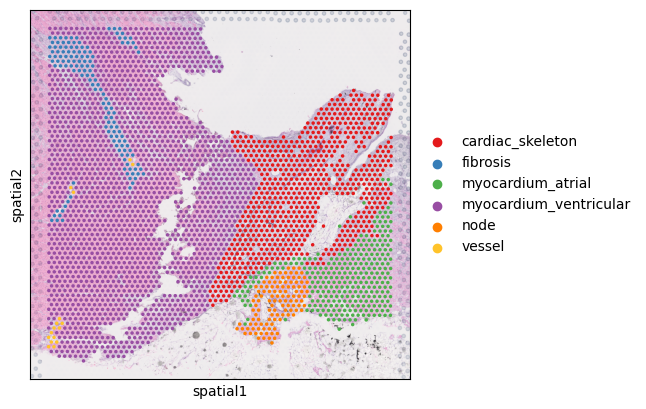

In [30]:
custom_palette = ["#E41A1C",
                 "#377EB8", 
                 "#4DAF4A", 
                 "#984EA3", 
                 "#FF7F00", 
                 "#FFC32A",
                 "#F22E96", "#FFFF33", "#A65628", "#999999"]
# custom_palette = ["#E87E72",
#                   "#C59833",
#                   "#87AD34",
#                   #"#56BB70",
#                   #"#56BCC2",
#                   "#4BA7F8",
#                   "#BD80F8",
#                   "#ED6CC8"]

sc.pl.spatial(
    adata_HCAHeartST11290662,
    library_id="HCAHeartST11290662",
    color="cell_type",
    title = "",
    palette=custom_palette
)

/tmp/ipykernel_479521/2267066598.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


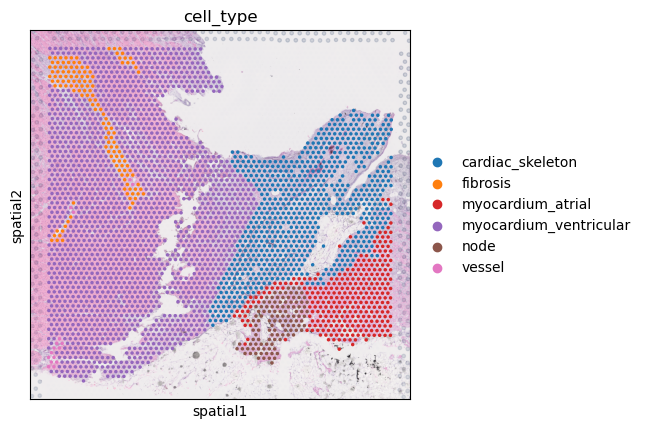

In [13]:
sc.pl.spatial(
    adata_HCAHeartST11290662,
    library_id="HCAHeartST11290662",
    img_key="hires",
    color="cell_type",
)


In [15]:
lib = "HCAHeartST11290662"
adata_HCAHeartST11290662.write_h5ad(slice_dir / f"{lib}_adata_final_annotation.h5ad")

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [ ]:
adata.var_names = adata.var["SYMBOL"].astype(str)

In [9]:
w_cell2loc.obsm["prop"].columns

Index(['Adip1', 'Adip2', 'Adip3', 'B', 'B_plasma', 'CD14+Mo', 'CD16+Mo',
       'CD4+T_act', 'CD4+T_naive', 'CD8+T_cytox', 'CD8+T_em', 'CD8+T_te',
       'CD8+T_trans', 'DC', 'EC10_CMC-like', 'EC1_cap', 'EC2_cap', 'EC3_cap',
       'EC4_immune', 'EC5_art', 'EC6_ven', 'EC7_endocardial', 'EC8_ln', 'FB1',
       'FB2', 'FB3', 'FB4_activated', 'FB5', 'FB6', 'ILC', 'LYVE1+IGF1+MP',
       'LYVE1+MP_cycling', 'LYVE1+TIMD4+MP', 'MAIT-like', 'Mast', 'Meso',
       'MoMP', 'NC1_glial', 'NC2_glial_NGF+', 'NK_CD16hi', 'NK_CD56hi', 'Neut',
       'PC1_vent', 'PC2_atria', 'PC3_str', 'SAN_P_cell', 'SMC1_basic',
       'SMC2_art', 'T/NK_cycling', 'aCM1', 'aCM2', 'aCM3', 'aCM4',
       'AVN_bundle_cell', 'PC4_CMC-like', 'vCM1', 'vCM2', 'vCM3_stressed',
       'vCM4', 'vCM5', 'AVN_P_cell', 'CD4+T_Tfh', 'CD4+T_Th1', 'CD4+T_Th2',
       'CD4+T_reg', 'NC5_glial', 'aCM5', 'Adip4', 'NC3_glial', 'NC6_schwann',
       'EC9_FB-like', 'gdT'],
      dtype='object')

In [11]:
w_cell2loc.obs.columns.to_list()

['array_row',
 'array_col',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'sangerID',
 'region',
 'donor',
 'donor_type',
 'age',
 'gender',
 'facility',
 'modality',
 'kit_10x',
 'flushed',
 'annotation_final',
 'Adip1',
 'Adip2',
 'Adip3',
 'B',
 'B_plasma',
 'CD14+Mo',
 'CD16+Mo',
 'CD4+T_act',
 'CD4+T_naive',
 'CD8+T_cytox',
 'CD8+T_em',
 'CD8+T_te',
 'CD8+T_trans',
 'DC',
 'EC10_CMC-like',
 'EC1_cap',
 'EC2_cap',
 'EC3_cap',
 'EC4_immune',
 'EC5_art',
 'EC6_ven',
 'EC7_endocardial',
 'EC8_ln',
 'FB1',
 'FB2',
 'FB3',
 'FB4_activated',
 'FB5',
 'FB6',
 'ILC',
 'LYVE1+IGF1+MP',
 'LYVE1+MP_cycling',
 'LYVE1+TIMD4+MP',
 'MAIT-like',
 'Mast',
 'Meso',
 'MoMP',
 'NC1_glial',
 'NC2_glial_NGF+',
 'NK_CD16hi',
 'NK_CD56hi',
 'Neut',
 'PC1_vent',
 'PC2_atria',
 'PC3_str',
 'SAN_P_cell',
 'SMC1_basic',
 'SMC2_art',
 'T/NK_cycling',
 'aCM1',
 'aCM2',
 'aCM3',
 'aCM4',
 'AVN_bundle_cell',
 'PC4_CMC-like',
 'vCM1',
 'vCM2',
 'vCM3_stressed',
 'vCM4',